**Análisis Estadístico de Señales**

**Segunda parte: *Acercamiento a la base de datos de arritmias cardiacas y comparación estadística***

Valentina Morales


Paula García

--Realizar un acercamiento a una base de datos de señales ECG, disponible en:
https://figshare.com/collections/ChapmanECG/4560497. Identificar sus principales características y
realizando un análisis estadístico que permita determinar si existen diferencias significativas entre los grupos
de sujetos con diferentes tipos de arritmias (utilizar los datos disponibles en los archivos filtrados
ECGDataDenoised.zip).

***1. Exploración y descripción de la base de datos***


Realice una exploración general de la base de datos proporcionada. Identifique y describa:

• Número total de registros y sujetos.

• Tipos de arritmias o clases disponibles.

• Número de sujetos o registros pertenecientes a cada grupo.

• Número de canales disponibles y sus correspondientes derivaciones.

• Frecuencia de muestreo y duración de los registros.
Presente esta información mediante tablas y, cuando sea pertinente, gráficos que permitan visualizar
la distribución de los datos entre las diferentes clases.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

Nuestra base de datos contiene:

**ECGDataDenoised.zip** 10 646 electrocardiogramas de 12 derivaciones de pacientes con una frecuencia de muestreo de 500 Hz, que incluyen 11 ritmos comunes y 67 afecciones, etiquetadas por expertos profesionales.

Se descarga adicionalmente el excel **Diagnostics.xlsx** esto con el fin de conocer las clases asignadas a cada archivo del zip.

In [29]:
# Cargamos los datos a usar y analizar
#SIGNALS_DIR = Path("ECGDataDenoised")
SIGNALS_DIR = Path("ECGDataDenoised") / "ECGDataDenoised"
DIAGNOSTICS_PATH = Path(r"Diagnostics.xlsx")

diag = pd.read_excel(DIAGNOSTICS_PATH)
FILENAME = "MUSE_20180113_134825_04000.csv" 
FS = 500  # Hz

#estas son las 12 columnas, en nuestro caso particular, nuestro objeto a analizar es la columna 2.
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
LEAD_INDEX = LEADS.index("II")  # = 1

In [31]:
#Número total de registros y sujetos. 
#Frecuencia de muestreo y duración de los registros
n_registros = len(diag)
n_sujetos = diag["FileName"].nunique()

resumen_general = pd.DataFrame({
    "Métrica": [
        "Número total de registros",
        "Número de sujetos únicos",
        "Número de clases (ritmos)",
        "Número de canales (derivaciones)",
        "Frecuencia de muestreo (Hz)",
        "Duración por registro (s)",
        "Muestras por registro",
    ],
    "Valor": [n_registros, n_sujetos, diag["Rhythm"].nunique(), 12, 500, 10, 5000],
})
resumen_general

,Métrica,Valor
0,Número total de registros,10646
1,Número de sujetos únicos,10646
2,Número de clases (ritmos),11
3,Número de canales (derivaciones),12
4,Frecuencia de muestreo (Hz),500
5,Duración por registro (s),10
6,Muestras por registro,5000


In [32]:
#Tipos de arritmias o clases disponibles. 
nombres_clases = {
    "SB": "Bradicardia sinusal",
    "SR": "Ritmo sinusal (normal)",
    "AFIB": "Fibrilación auricular",
    "ST": "Taquicardia sinusal",
    "SVT": "Taquicardia supraventricular",
    "AF": "Aleteo/Flutter auricular",
    "SA": "Arritmia sinusal",
    "AT": "Taquicardia auricular",
    "AVNRT": "Taquicardia reentrante nodal AV",
    "AVRT": "Taquicardia reentrante AV",
    "SAAWR": "Ritmo auricular migratorio",
}

tabla_clases = diag["Rhythm"].value_counts().rename_axis("Código").reset_index(name="N_sujetos")
tabla_clases["Nombre completo"] = tabla_clases["Código"].map(nombres_clases)
tabla_clases["Porcentaje (%)"] = (100 * tabla_clases["N_sujetos"] / n_registros).round(2)
tabla_clases = tabla_clases[["Código", "Nombre completo", "N_sujetos", "Porcentaje (%)"]]
tabla_clases

,Código,Nombre completo,N_sujetos,Porcentaje (%)
0,SB,Bradicardia sinusal,3889,36.53
1,SR,Ritmo sinusal (normal),1826,17.15
2,AFIB,Fibrilación auricular,1780,16.72
3,ST,Taquicardia sinusal,1568,14.73
4,SVT,Taquicardia supraventricular,587,5.51
5,AF,Aleteo/Flutter auricular,445,4.18
6,SA,Arritmia sinusal,399,3.75
7,AT,Taquicardia auricular,121,1.14
8,AVNRT,Taquicardia reentrante nodal AV,16,0.15
9,AVRT,Taquicardia reentrante AV,8,0.08


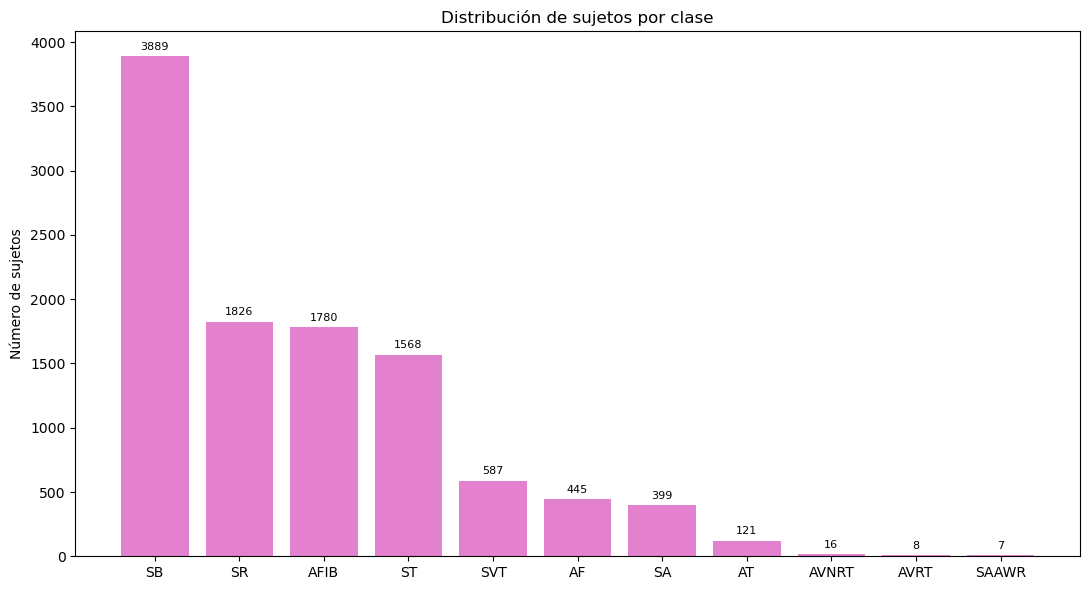

In [33]:
#Grafico de barras para visualizar la distribución de sujetos por clase
plt.figure(figsize=(11, 6))
plt.bar(tabla_clases["Código"], tabla_clases["N_sujetos"], color="#E381CF")
plt.ylabel("Número de sujetos")
plt.title(f"Distribución de sujetos por clase")
for i, v in enumerate(tabla_clases["N_sujetos"]):
    plt.text(i, v + 50, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

In [34]:
#Número de canales disponibles y sus correspondientes derivaciones. 
tabla_canales = pd.DataFrame({
    "N° de columna": list(range(1, 13)),
    "Derivación": ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"],
})
tabla_canales

,N° de columna,Derivación
0,1,I
1,2,II
2,3,III
3,4,aVR
4,5,aVL
5,6,aVF
6,7,V1
7,8,V2
8,9,V3
9,10,V4


**2. Visualización y caracterización de las señales**


Seleccione dos registros de dos tipos tipo de arritmia. Realice una breve consulta de esas dos arritmias
y realice una visualización de las señales ECG. Analice los aspectos como la morfología, amplitud,
frecuencia cardíaca y regularidad de los latidos.


Ya que logramos identificar las clases del archivo de diagnosticos, procedemos a elegir dos de ellas, para nuestro posterior analisis.
Para esto tenemos en cuenta dos arritmias con iguales o similares numeros de sujetos, esto se hace con el fin de poder obtener resultados comparables entre ambas, y evitar sesgos.

En este caso, usaremos AF -Aleteo- Y SA -Arritmia sinusual-
Con una diferencia de 46 sujetos.

**ALETEO**

El aleteo/flutter auricular es un tipo de trastorno del ritmo cardiaco, conocido como arritmia. Esta es causada por un circuito de macrorrentrada en las aurículas (con mayor frecuencia en la derecha), que se perpetúa de forma circular en el interior de la misma.
Durante el aleteo, se produce una estimulación auricular con frecuencias elevadas, entre 240 y 350 lpm. Ademas de eso, se caracteriza por manejar un ritmo cardiaco 'organizado' y menos caótico que en la fibrilación auricular, que es otro tipo de arritmia, a la cual se suele asociar semejanzas con el aleteo. 

Este tipo de arritmia, puede no causar sintomas, sin embargo; algunas personas llegan a tener latidos cardíacos rápidos y fuertes y dolor en el pecho. Ademas, de estar expuestos a sufrir eventos tromboembólicos. 
Finalmente, el tratamiento del aleteo auricular se basa en medicamentos y procedimientos cardíacos. [1][2]

***Electrocardiograma del flutter auricular***

En términos de ECG, podemos decir que el lutter auricular se logra reconocer en el electrocardiograma por ser una taquicardia rítmica con frecuencias cardiacas cercanas a valores divisores de 300 lpm, la más frecuente en pacientes sin tratamiento es a 150 lpm (conducción AV 2:1).
Ademas de esto, no presentan ondas P, observándose ondas auriculares en diente de sierra (llamadas ondas F, por el flutter) con frecuencias en torno a 300 lpm.
El QRS es estrecho salvo que el paciente presente un bloqueo de rama o conducción aberrante, y en determinados casos puede tener conducción variable y ser arrítmico, pudiendo confundirse con la fibrilación auricular. La presencia de las ondas en «dientes de sierra» es lo que permite realizar el diagnóstico. [2]

https://www.mayoclinic.org/es/diseases-conditions/atrial-flutter/symptoms-causes/syc-20352586

https://www.my-ekg.com/arritmias-cardiacas/flutter-auricular.html

**Arritmia sinusal**

La arritmia sinusal es una desviación común y natural de la frecuencia cardíaca en reposo, que se origina en el nódulo sinoauricular. Se observa con mayor frecuencia en niños y adultos jóvenes. 
Generalmente se asocia con la respiración y puede detectarse como un aumento de la frecuencia cardíaca durante la inspiración y una disminución de la frecuencia cardíaca durante la espiración.

Los pacientes con este tipo de arritmia suelen no presentar sintomas, y  cuando los presentan, son síntomas como dificultad para respirar o disnea probablemente reflejen alguna otra afección subyacente y no arritmia sinusal. En el caso definitivo, es conveniente realizar un ECG. [3][4]

***Electrocardiograma de la Arritmia Sinusual***

En el ECG, el ritmo sinusal aparece como una variación latido a latido en el intervalo PP. Típicamente, esta variación es mayor de 120 ms: el intervalo PP aumenta y disminuye con la inspiración y la espiración..
Las ondas P suelen ser monoformes y presentan un patrón compatible con la activación auricular originada en el nódulo sinusal. [3]


https://www.ncbi.nlm.nih.gov/books/NBK537011/

https://www.thecardiologyadvisor.com/ddi/sinus-arrhythmia/

Antes de comparar las señales, se resumen las características ECG esperadas para cada
ritmo según la literatura clínica. 

### Aleteo / Flutter auricular (AF)
Fuente: [Atrial Flutter — LITFL ECG Library](https://litfl.com/atrial-flutter-ecg-library/)

| Aspecto | Característica esperada |
|---|---|
| **Morfología** | Ondas F (flutter) en patrón de "dientes de sierra" (*sawtooth*), continuas, sin línea isoeléctrica entre ellas. En el flutter típico (antihorario): ondas negativas en II, III, aVF y positivas en V1. |
| **Frecuencia** | Frecuencia auricular regular entre 250–350 lpm (típicamente ~300 lpm). Con conducción AV 2:1 (la más común), la frecuencia ventricular (QRS) resultante es ~150 lpm. |
| **Regularidad** | Muy regular — tanto la actividad auricular como, generalmente, los QRS (a diferencia de la fibrilación auricular, que es irregularmente irregular). |
| **Amplitud** | Ondas F más prominentes/positivas en V1–V2; de menor amplitud en otras derivaciones. |

### Arritmia sinusal (SA)
Fuente: [Sinus Arrhythmia — LITFL ECG Library](https://litfl.com/sinus-arrhythmia-ecg-library/)
(comparar también con [Normal Sinus Rhythm — LITFL](https://litfl.com/normal-sinus-rhythm-ecg-library/))

| Aspecto | Característica esperada |
|---|---|
| **Morfología** | Ondas P sinusales normales, de morfología constante (sin contracciones auriculares prematuras); intervalo PR constante. |
| **Frecuencia** | Dentro de rango normal, pero **variable** de forma cíclica: aumenta con la inspiración (↓ tono vagal) y disminuye con la espiración (↑ tono vagal). |
| **Regularidad** | Variación del intervalo P-P ≥ 120 ms de forma cíclica (ligada a la respiración) — es la característica que la distingue del ritmo sinusal normal, que es regular. Es un fenómeno fisiológico normal, más frecuente en personas jóvenes y sanas. |
| **Amplitud** | Amplitud de onda P/QRS normal; no hay alteración de amplitud esperada por sí misma (a diferencia de la morfología/regularidad). |

In [35]:
grupo_a, grupo_b = "AF", "SA"
subset = diag[diag["Rhythm"].isin([grupo_a, grupo_b])].reset_index(drop=True)

conteo = subset["Rhythm"].value_counts()
print(conteo)
subset.head()

Rhythm
AF    445
SA    399
Name: count, dtype: int64


,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
1,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354
2,MUSE_20180119_175205_68000,SA,NONE,18,MALE,60,60,98,406,406,88,53,10,218,267,421
3,MUSE_20180712_153037_41000,AF,AVB,81,MALE,83,72,94,404,474,30,7,14,209,256,411
4,MUSE_20180112_071549_54000,SA,NONE,35,MALE,74,74,96,358,397,58,38,12,216,264,395


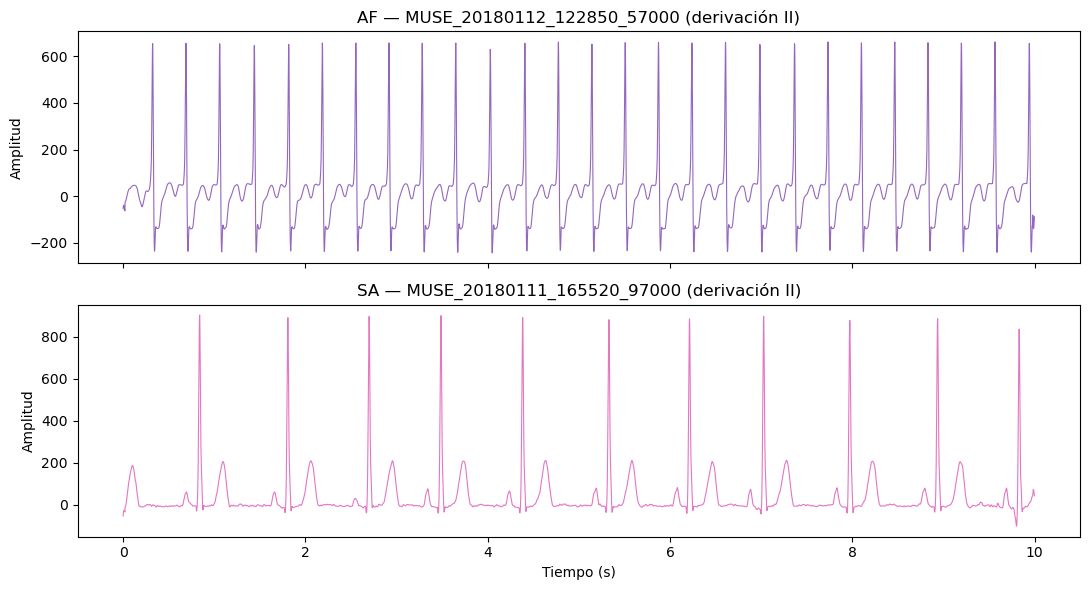

In [36]:
ejemplo_a = subset[subset["Rhythm"] == grupo_a].iloc[0]["FileName"]
ejemplo_b = subset[subset["Rhythm"] == grupo_b].iloc[0]["FileName"]

colores = {grupo_a: "tab:purple", grupo_b: "tab:pink"}

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, filename, etiqueta in zip(axes, [ejemplo_a, ejemplo_b], [grupo_a, grupo_b]):
    señal = pd.read_csv(SIGNALS_DIR / f"{filename}.csv", header=None)
    tiempo = señal.index / FS
    ax.plot(tiempo, señal.iloc[:, LEAD_INDEX], linewidth=0.8, color=colores[etiqueta])
    ax.set_title(f"{etiqueta} — {filename} (derivación II)")
    ax.set_ylabel("Amplitud")
axes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

Aca observamos dos ejemplos, uno de cada clase. 

1. En la primera señal, de AF, se observa lo que teoricamente se esperaba encontrar. Primero, se observan los picos QRS bastante estrechos, estos son los que mas sobresalen y mayor amplitud tiene, se podria decir que alcanzan un poco mas de 620. Tambien podemos analizar que no se observan Ondas P, en su caso contrario, encontramos un patrón que son los dientes de sierra, que estan entre las ondas QRS. Los picos en general, pues el patrón siempre se observan mas cercas del uno al otro, lo que se explica en teoría por una mayor frecuencia cardiaca. 
Es un patrón regular, no se observan cambios abruptos de un periodo a otro.

2. En la segunda señal, en este caso SA, observamos algo muy distinto y mas claro que la primera señal analizada, ya que aca observamos con mayor detalle las ondas QRS, ondas P y ondas T. Las ondas P son aquellos picos chiquitos antes de las ondas QSR, mientras que las que le siguen a estas ondas, son las T, ademas de eso el patrón visualmente parece uniforme, aunque la teoría anticipa una variabilidad cíclica que un fragmento de 10 s puede no capturar del todo.La amplitud maxima que alcanza es aprx mayor a valores de 900. 

**3. Análisis estadístico entre arritmias**


Calcule y compare mediante un análisis descriptivo (box plots, diagramas de densidad, etc.) las
siguientes características descriptivas: media, desviación estándar, valor máximo, valor mínimo,
frecuencia cardíaca y el valor RMS.

Formule una hipótesis nula y una hipótesis alternativa con las arritmias escogidas anteriormente.

Antes de aplicar una prueba estadística paramétrica, compruebe los supuestos necesarios para realizar
una prueba t de Student.

Si los supuestos se cumplen, realice la prueba t de Student para muestras
independientes con el fin de determinar si existen diferencias estadísticamente significativas entre los
grupos de arritmias. Si no se cumple el supuesto de normalidad o las condiciones necesarias para
utilizar la prueba t, realice un análisis no paramétrico mediante la prueba U de Mann-Whitney,
apropiada para comparar dos grupos independientes.

In [37]:
from scipy.signal import find_peaks
from scipy import stats
import numpy as np

def rms(x):
    return np.sqrt(np.mean(x**2))
def caracteristicas_derivacion_ii(filename, fs=FS):
    señal = pd.read_csv(SIGNALS_DIR / f"{filename}.csv", header=None)
    lead_ii = señal.iloc[:, LEAD_INDEX].values
    return {
        "media": lead_ii.mean(),
        "std": lead_ii.std(),
        "maximo": lead_ii.max(),
        "minimo": lead_ii.min(),
        "rms": rms(lead_ii),
    }

registros = []
for _, fila in subset.iterrows():
    car = caracteristicas_derivacion_ii(fila["FileName"])
    car["FileName"] = fila["FileName"]
    car["Rhythm"] = fila["Rhythm"]
    registros.append(car)

df_stats = pd.DataFrame(registros)
variables = ["media", "std", "maximo", "minimo", "rms"]
df_stats.head()

#como head solo muestra las primeras 5 filas, para ver todas las filas de la tabla, se puede usar el siguiente comando:
pd.set_option("display.max_rows", None)
df_stats

,media,std,maximo,minimo,rms,FileName,Rhythm
0,41.646767,122.908281,903.820,-102.490,129.772488,MUSE_20180111_165520_97000,SA
1,17.605216,137.861893,661.680,-242.470,138.981456,MUSE_20180112_122850_57000,AF
2,54.568941,163.277091,913.150,-471.310,172.154517,MUSE_20180119_175205_68000,SA
3,16.112115,72.695423,459.530,-157.000,74.459551,MUSE_20180712_153037_41000,AF
4,47.240664,133.906109,819.220,-112.130,141.994811,MUSE_20180112_071549_54000,SA
5,8.289258,89.430452,491.100,-314.030,89.813794,MUSE_20180114_134540_25000,AF
6,5.493750,95.423141,374.600,-441.020,95.581155,MUSE_20180712_152550_20000,AF
7,60.548118,211.418040,955.430,-119.920,219.917398,MUSE_20180111_163519_23000,AF
8,31.592397,155.376507,1316.800,-438.680,158.555790,MUSE_20180114_065653_76000,SA
9,66.690058,298.973713,1908.800,-153.200,306.321473,MUSE_20180115_134019_40000,AF


In [39]:
tabla_descriptiva = df_stats.groupby("Rhythm")[variables].agg(["mean", "std", "min", "max"])
tabla_descriptiva

media                                           std             \
             mean       std         min         max        mean        std   
Rhythm                                                                       
AF      22.070811  35.50191 -143.397735  170.326222  151.732487  81.550134   
SA      45.062402  22.88916  -23.351639  113.589833  163.108845  59.109715   

                                    maximo                              \
              min         max         mean         std     min     max   
Rhythm                                                                   
AF      31.886917  578.794972   779.246971  457.323621   70.20  3080.1   
SA      38.184606  439.165175  1129.308847  447.770389  208.39  2951.6   

            minimo                                     rms             \
              mean         std     min     max        mean        std   
Rhythm                                                                  
AF     -318.127463  317.939562 -3167.8 -22.538  155.580088  84.934967   
SA     -254.432897  191.443665 -1083.7 -22.566  169.803032  61.801460   

                               
              min         max  
Rhythm                         
AF      31.909360  600.330718  
SA      38.825098  451.510863

Comparación descriptiva AF vs SA — derivación II


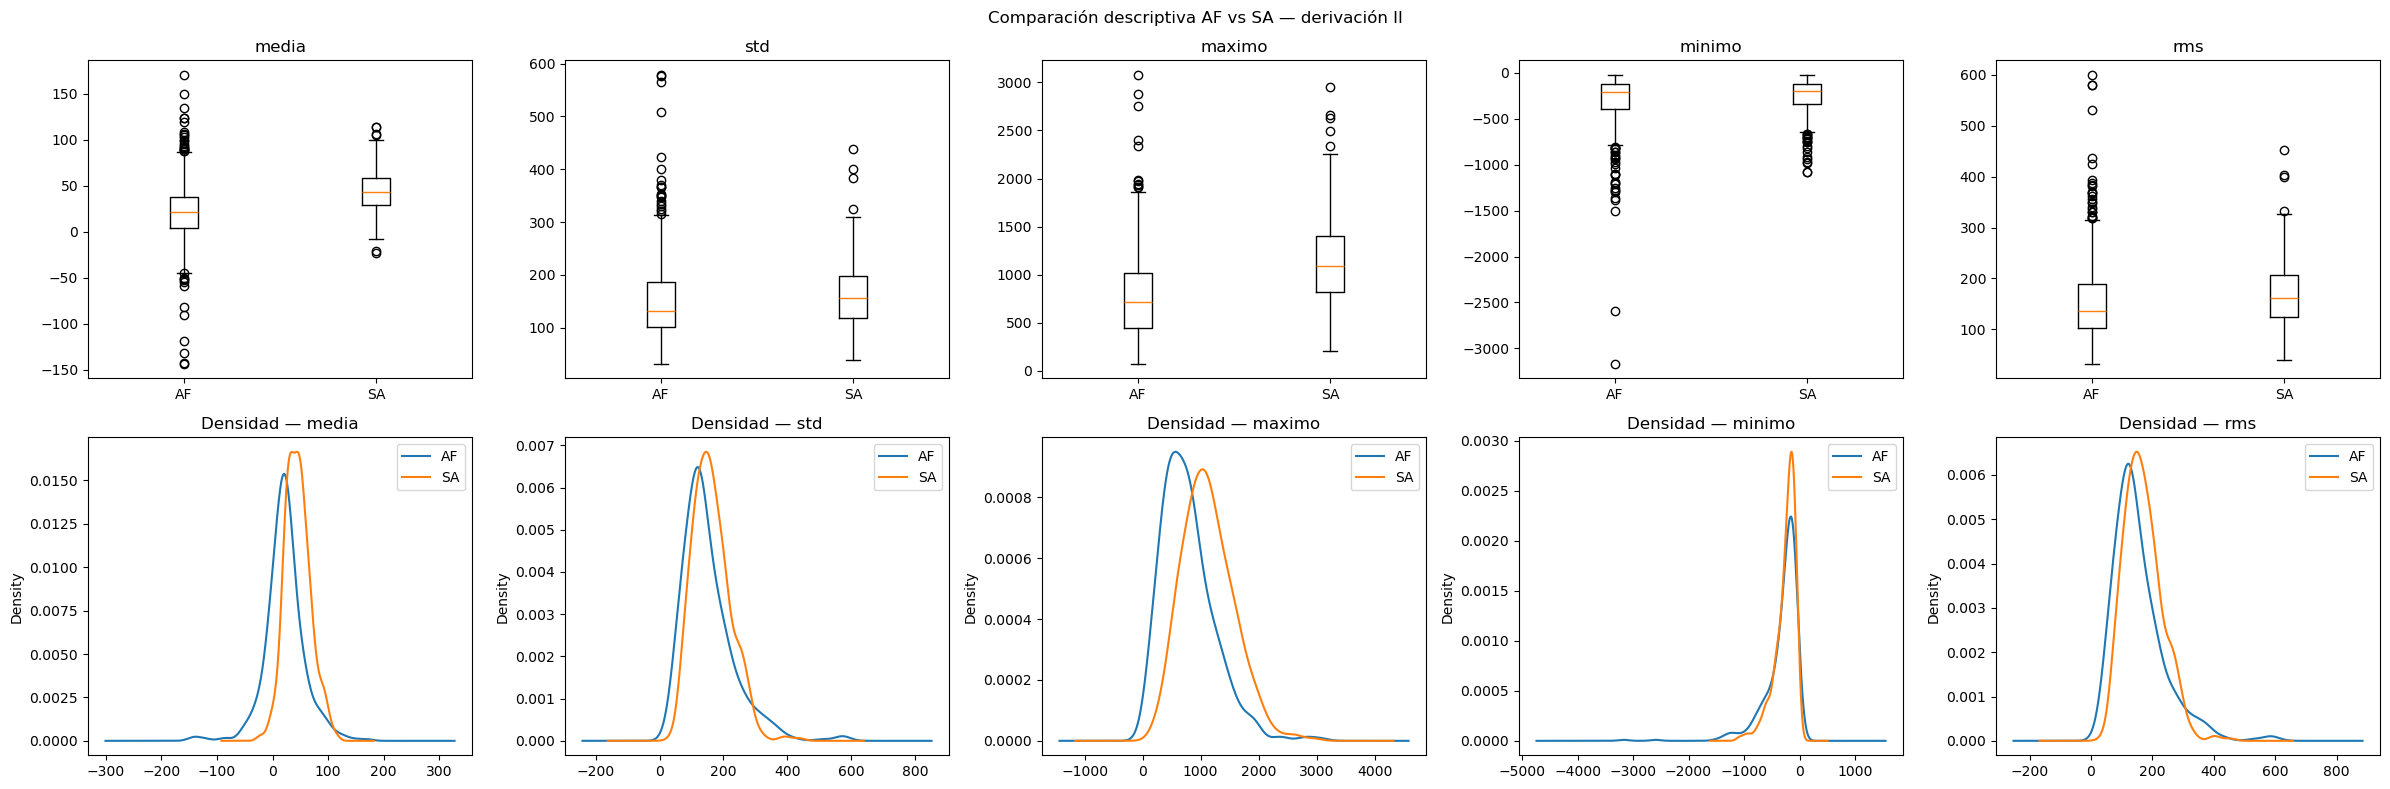

In [38]:

print(f"Comparación descriptiva {grupo_a} vs {grupo_b} — derivación II")

fig, axes = plt.subplots(2, len(variables), figsize=(24, 8))

for i, var in enumerate(variables):
    datos_a = df_stats[df_stats["Rhythm"] == grupo_a][var].dropna()
    datos_b = df_stats[df_stats["Rhythm"] == grupo_b][var].dropna()

    axes[0, i].boxplot([datos_a, datos_b], tick_labels=[grupo_a, grupo_b])
    axes[0, i].set_title(var)

    try:
        datos_a.plot(kind="density", ax=axes[1, i], label=grupo_a)
        datos_b.plot(kind="density", ax=axes[1, i], label=grupo_b)
        axes[1, i].legend()
    except Exception:
        axes[1, i].text(0.5, 0.5, "Varianza insuficiente\npara estimar densidad",
                        ha="center", va="center", transform=axes[1, i].transAxes)
    axes[1, i].set_title(f"Densidad — {var}")

fig.suptitle(f"Comparación descriptiva {grupo_a} vs {grupo_b} — derivación II")
plt.tight_layout()
plt.show()

## Análisis de diagramas de caja y bigotes

En general, en las variables evaluadas encontramos una particularidad: el Aleteo (AF) es el grupo que presenta una mayor dispersión de datos en casi todos los casos.

En la **media**, observamos que ambos grupos contienen su mediana dentro de la caja del otro, por esa "coincidencia" que se llega a ver entre las cajas. Pero en el caso de SA son pocos los datos que se salen de ese rango, no se encuentran tan dispersos, como sí pasa en AF, donde vemos mucha superposición y demasiados datos por fuera de los bigotes.

En la **desviación estándar** encontramos una similitud mayor entre ambas cajas y bigotes, pero igual con mayor prevalencia de dispersión en AF.

En los valores **máximo y mínimo** también se observa un comportamiento parecido, aunque en el mínimo ambos grupos sí logran una mayor dispersión, pero AF sigue con datos aún más alejados del resto.

Finalmente, en el **RMS** el análisis es similar al de la desviación estándar.

## Análisis de diagramas de densidad

Ahora, mirando las densidades, se confirma bastante lo que ya veíamos en las cajas.

En la **media**, las curvas se superponen bastante y quedan centradas en zonas parecidas, pero la de AF se ve más ancha y achatada, con colas más largas hacia los dos lados — eso concuerda con la mayor dispersión que ya habíamos visto. La de SA en cambio es más angosta y alta, señal de que sus datos están más concentrados.

En la **desviación estándar**, los picos de ambas curvas quedan bastante cerca y se superponen, pero AF tiene una cola hacia la derecha más larga (o sea, más casos con desviación alta), mientras que SA tiene un pico un poco más alto y más estrecho.

En el **máximo** es donde se nota la diferencia más clara entre las dos curvas: el pico de AF queda corrido hacia la izquierda (como en 700-800) y el de SA hacia la derecha (como en 1100). Aunque hay una parte donde se superponen, los dos picos se distinguen bien — es la variable donde mejor se ve la diferencia entre los dos grupos.

En el **mínimo**, las curvas se superponen bastante en la parte central, pero AF tiene una cola hacia la izquierda más larga y pesada, llegando a valores bien negativos (por ese dato atípico que se ve cerca de -3000), lo que hace su distribución más sesgada que la de SA, que se ve más compacta.

Y en el **RMS** pasa algo parecido a lo de la desviación estándar: picos cercanos, bastante superposición, pero AF con una cola más pesada hacia la derecha y SA más concentrado.


***HIPOTESIS***

Ahora, teniendo claro el punto anterior, donde encontramos que la variable que mas nos muestra diferencia entre ambas variables es el máximo, este será el factor clave al plantear las hipotesis.

- **H0 (hipótesis nula):** No existe diferencia estadísticamente significativa en la media
  del valor máximo de la señal (derivación II) entre los sujetos con AF y los sujetos con SA.
  (μ_AF = μ_SA)
- **H1 (hipótesis alternativa):** Existe una diferencia estadísticamente significativa en la
  media del valor máximo de la señal entre los sujetos con AF y los sujetos con SA.
  (μ_AF ≠ μ_SA)

Se usa un nivel de significancia α = 0.05 para todas las pruebas.

Analisis


Verificación de supuestos para la prueba t de Student

Antes de aplicar la prueba t, se debe comprobar:
1. **Normalidad** en cada grupo (prueba de Shapiro-Wilk): p > 0.05 → no se rechaza normalidad.
2. **Homogeneidad de varianzas** entre los dos grupos (prueba de Levene): p > 0.05 → varianzas
   homogéneas.

Si ambos supuestos se cumplen → prueba t de Student (varianzas iguales).
Si hay normalidad pero varianzas distintas → prueba t de Welch (varianzas distintas).
Si no hay normalidad en alguno de los grupos → prueba U de Mann-Whitney (no paramétrica).

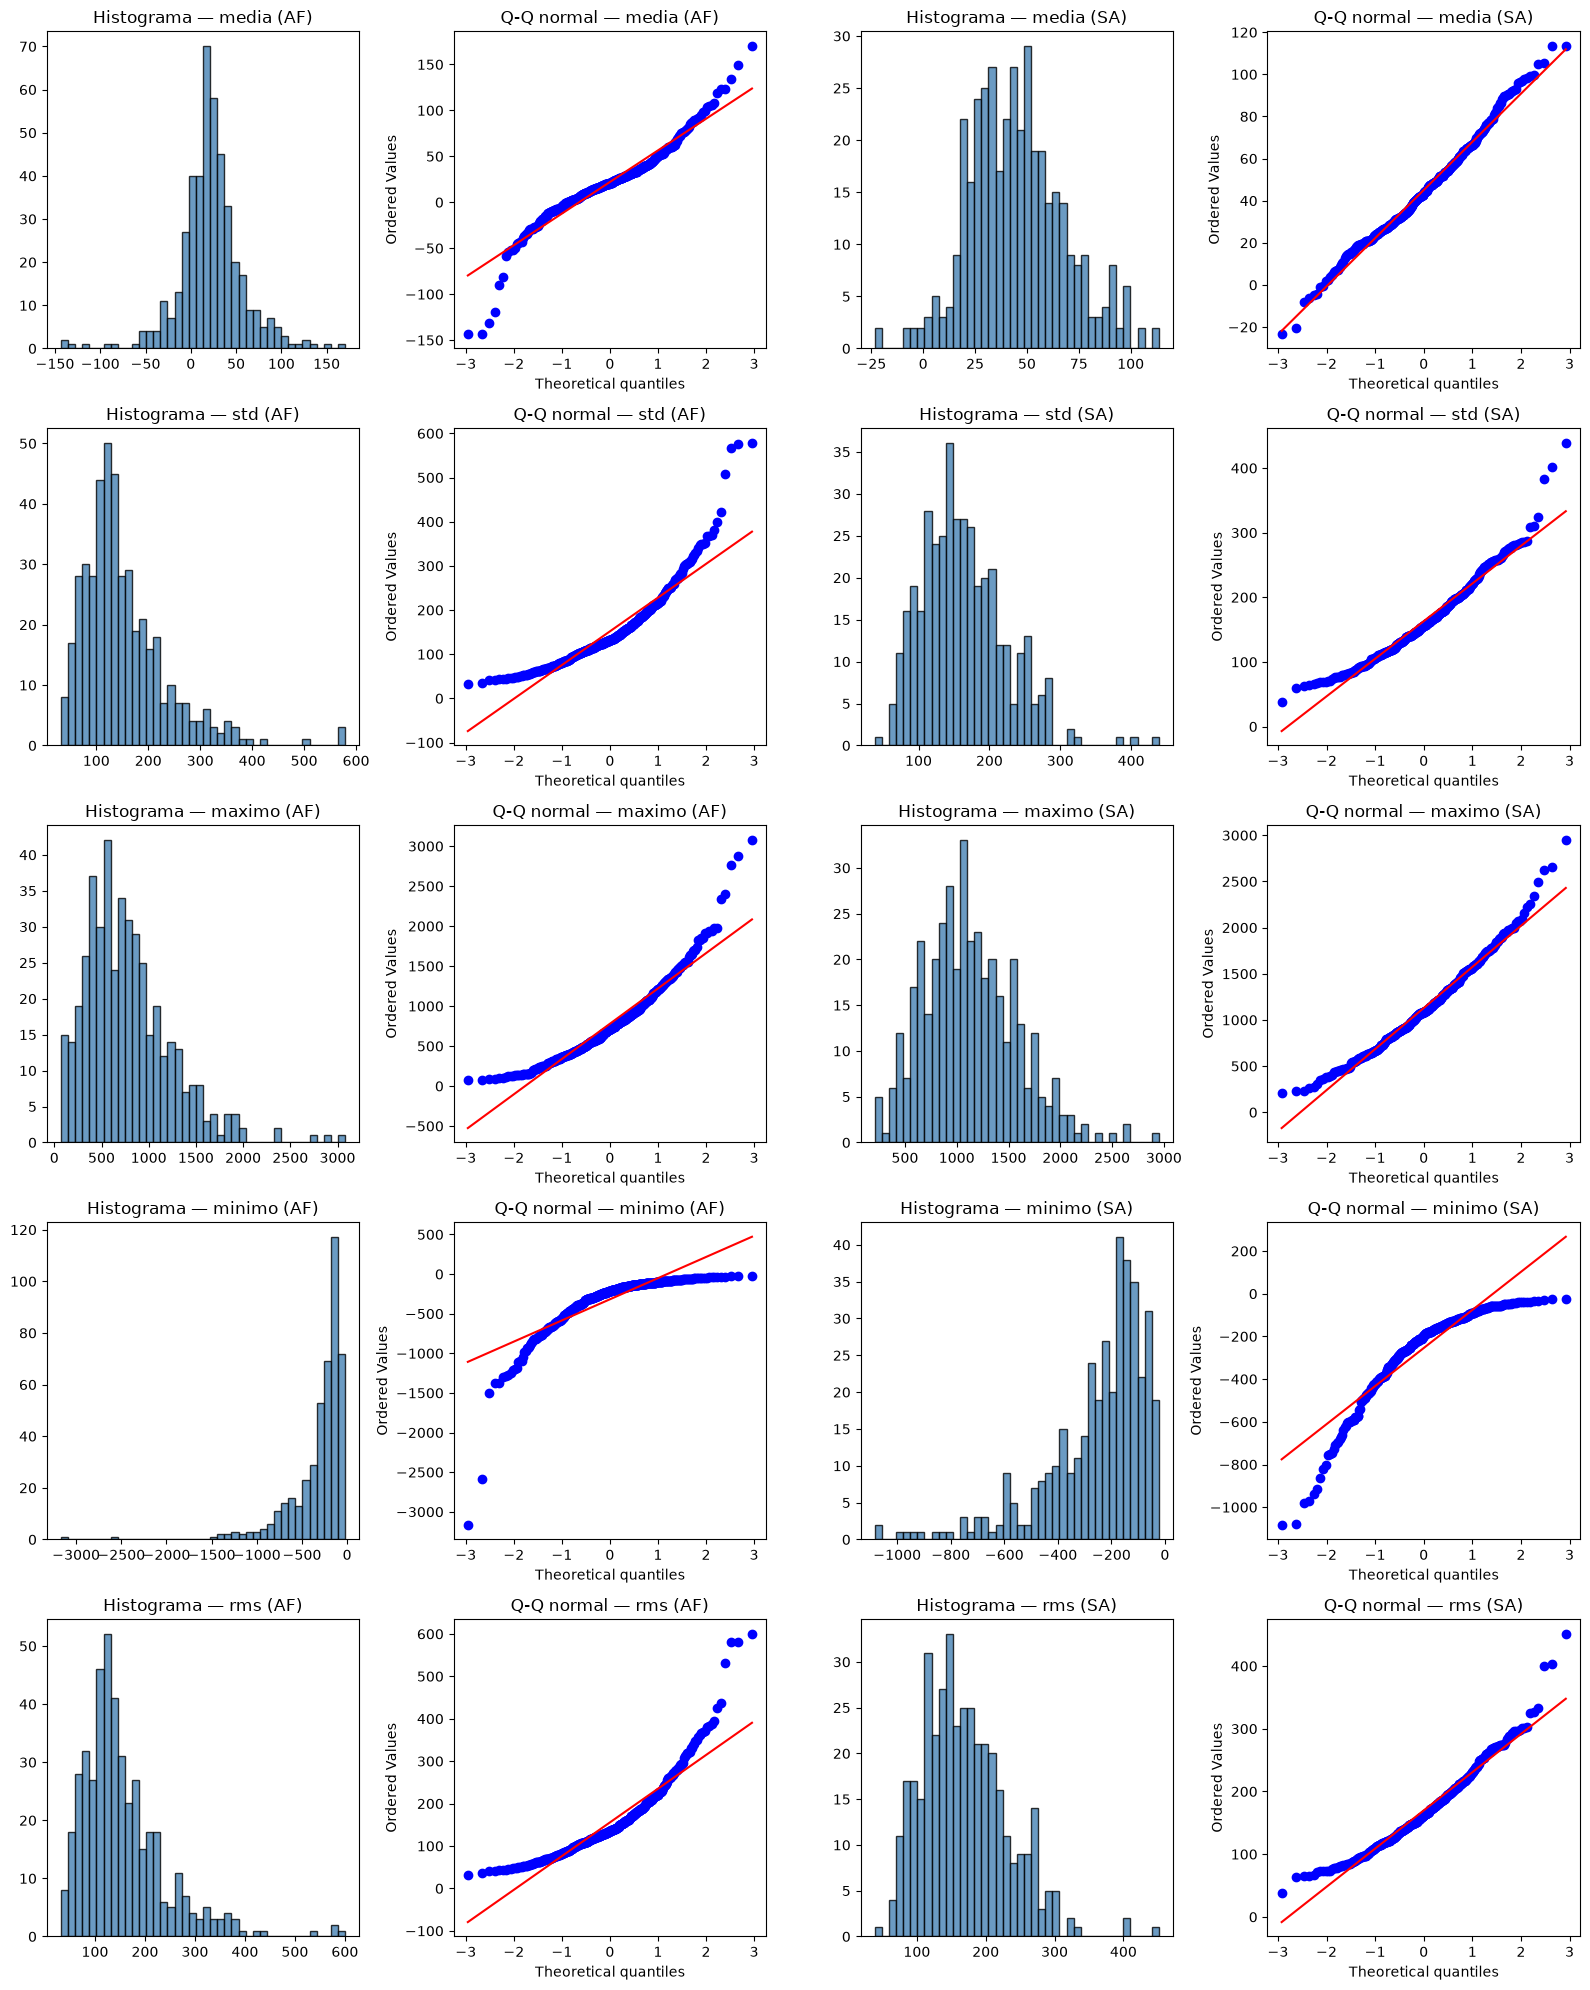

In [26]:
fig, axs = plt.subplots(len(variables), 4, figsize=(16, 4 * len(variables)))

for fila, var in enumerate(variables):
    for col, (grupo, etiqueta) in enumerate([(grupo_a, grupo_a), (grupo_b, grupo_b)]):
        datos = df_stats[df_stats["Rhythm"] == grupo][var].dropna()
        axs[fila, 2*col].hist(datos, bins=40, color="steelblue", edgecolor="k", alpha=0.8)
        axs[fila, 2*col].set_title(f"Histograma — {var} ({etiqueta})")
        stats.probplot(datos, dist="norm", plot=axs[fila, 2*col + 1])
        axs[fila, 2*col + 1].set_title(f"Q-Q normal — {var} ({etiqueta})")

plt.tight_layout()
plt.show()

¿Por qué se hace esta verificación (histograma + Q-Q)?

Antes de decidir si se puede usar la prueba t de Student, hay que comprobar si los datos siguen una distribución normal, porque la t de Student solo es válida bajo ese supuesto. El histograma muestra la forma de la distribución (si es simétrica tipo campana, o si tiene sesgo/colas largas), y el gráfico Q-Q compara los datos reales contra lo que se esperaría si fueran normales: entre más se alejen los puntos azules de la línea roja, menos normal es la variable.

En este caso, en las 5 variables (media, std, máximo, mínimo, rms) y en ambos grupos (AF y SA), se observan histogramas con sesgo y colas pesadas, y en los Q-Q los puntos se despegan claramente de la línea roja en los extremos. Esto confirma visualmente que ninguna variable cumple el supuesto de normalidad, por lo que la prueba adecuada para comparar los grupos es la no paramétrica (U de Mann-Whitney) en vez de la t de Student. Pero antes de eso, es ideal corroborar con Shapiro Wilk que es una prueba cuantitativa que nos permite verificar lo que visualmente acabamos de observar, y asi proceder al analisis estadistico ideal.

In [41]:
def comparar_grupos(g1, g2, n1, n2, alpha=0.05):
    print("=" * 62)
    print(f"COMPARACIÓN: {n1} vs {n2}")
    print("=" * 62)
    print(f"{n1}: n = {len(g1):4d} | media = {np.mean(g1):8.2f} | var = {np.var(g1, ddof=1):10.2f}")
    print(f"{n2}: n = {len(g2):4d} | media = {np.mean(g2):8.2f} | var = {np.var(g2, ddof=1):10.2f}")

    # Supuesto 1: Normalidad (Shapiro-Wilk sobre cada grupo)
    # H0: la muestra proviene de una distribución normal
    W1, p1 = stats.shapiro(g1)
    W2, p2 = stats.shapiro(g2)
    print("\n1) NORMALIDAD (Shapiro-Wilk)")
    print(f"   {n1}: W = {W1:.4f}, p = {p1:.3e}  ->  {'normal' if p1 > alpha else 'NO normal'}")
    print(f"   {n2}: W = {W2:.4f}, p = {p2:.3e}  ->  {'normal' if p2 > alpha else 'NO normal'}")
    normalidad = (p1 > alpha) and (p2 > alpha)

    # Supuesto 2: Independencia
    print("\n2) INDEPENDENCIA")
    print("   Se asume por diseño: son sujetos distintos, cada uno con un único registro.")

    # Supuesto 3: Homocedasticidad (Levene)
    # H0: las varianzas de los dos grupos son iguales
    L, pL = stats.levene(g1, g2, center="median")
    print("\n3) HOMOCEDASTICIDAD (Levene)")
    print(f"   W = {L:.4f}, p = {pL:.4f}  ->  {'varianzas iguales' if pL > alpha else 'VARIANZAS DIFERENTES'}")
    homoced = pL > alpha

    # Prueba t
    # H0: las medias de los dos grupos son iguales
    tstat, pt = stats.ttest_ind(g1, g2, equal_var=homoced)
    tipo = "Student (equal_var=True)" if homoced else "Welch (equal_var=False)"
    print(f"\n4) PRUEBA t - {tipo}")
    print(f"   t = {tstat:.4f}, p = {pt:.4f}  ->  {'NO hay diferencia significativa' if pt > alpha else 'SÍ hay diferencia significativa'}")

    # Tamaño del efecto: mide la MAGNITUD de la diferencia, no solo si existe
    sp = np.sqrt(((len(g1)-1)*np.var(g1, ddof=1) + (len(g2)-1)*np.var(g2, ddof=1)) / (len(g1)+len(g2)-2))
    d = (np.mean(g1) - np.mean(g2)) / sp
    print(f"   Tamaño del efecto (d de Cohen) = {d:.4f}  ->  {'pequeño' if abs(d) < 0.5 else 'moderado/grande'}")

    resultado = {
        "Variable": None,  # se completa al llamar la función
        "p_normalidad_AF": p1, "p_normalidad_SA": p2, "Normalidad_cumplida": normalidad,
        "p_levene": pL, "Varianzas_iguales": homoced,
        "Prueba_usada": tipo, "Estadistico": tstat, "p_valor": pt,
        "Diferencia_significativa (p<0.05)": pt < alpha,
        "Cohen_d": d,
    }

    # Alternativa no paramétrica si falla la normalidad
    if not normalidad:
        # H0: las dos muestras provienen de la misma distribución
        U, pu = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        print("\n5) NO SE CUMPLE NORMALIDAD -> PRUEBA U DE MANN-WHITNEY")
        print(f"   U = {U:.1f}, p = {pu:.4f}  ->  {'NO hay diferencia significativa' if pu > alpha else 'SÍ hay diferencia significativa'}")
        resultado["Prueba_usada"] = "U de Mann-Whitney (no paramétrica)"
        resultado["Estadistico"] = U
        resultado["p_valor"] = pu
        resultado["Diferencia_significativa (p<0.05)"] = pu < alpha
    print()
    return resultado


resultados = []
for var in variables:
    g1 = df_stats[df_stats["Rhythm"] == grupo_a][var].dropna()
    g2 = df_stats[df_stats["Rhythm"] == grupo_b][var].dropna()
    r = comparar_grupos(g1, g2, grupo_a, grupo_b)
    r["Variable"] = var
    resultados.append(r)

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados

COMPARACIÓN: AF vs SA
AF: n =  445 | media =    22.07 | var =    1260.39
SA: n =  399 | media =    45.06 | var =     523.91

1) NORMALIDAD (Shapiro-Wilk)
   AF: W = 0.9343, p = 4.303e-13  ->  NO normal
   SA: W = 0.9895, p = 5.955e-03  ->  NO normal

2) INDEPENDENCIA
   Se asume por diseño: son sujetos distintos, cada uno con un único registro.

3) HOMOCEDASTICIDAD (Levene)
   W = 17.9706, p = 0.0000  ->  VARIANZAS DIFERENTES

4) PRUEBA t - Welch (equal_var=False)
   t = -11.2924, p = 0.0000  ->  SÍ hay diferencia significativa
   Tamaño del efecto (d de Cohen) = -0.7612  ->  moderado/grande

5) NO SE CUMPLE NORMALIDAD -> PRUEBA U DE MANN-WHITNEY
   U = 45925.0, p = 0.0000  ->  SÍ hay diferencia significativa

COMPARACIÓN: AF vs SA
AF: n =  445 | media =   151.73 | var =    6650.42
SA: n =  399 | media =   163.11 | var =    3493.96

1) NORMALIDAD (Shapiro-Wilk)
   AF: W = 0.8706, p = 8.754e-19  ->  NO normal
   SA: W = 0.9611, p = 8.852e-09  ->  NO normal

2) INDEPENDENCIA
   Se asume 

,Variable,p_normalidad_AF,p_normalidad_SA,Normalidad_cumplida,p_levene,Varianzas_iguales,Prueba_usada,Estadistico,p_valor,Diferencia_significativa (p<0.05),Cohen_d
0,media,4.303077e-13,5.954540e-03,False,0.000025,False,U de Mann-Whitney (no paramétrica),45925.0,8.377141e-34,True,-0.761216
1,std,8.753518e-19,8.852127e-09,False,0.002100,False,U de Mann-Whitney (no paramétrica),72874.0,6.874476e-06,True,-0.158396
2,maximo,2.954254e-14,8.822473e-06,False,0.710811,True,U de Mann-Whitney (no paramétrica),48162.0,1.544912e-30,True,-0.773048
3,minimo,3.005414e-27,1.780861e-18,False,0.000247,False,U de Mann-Whitney (no paramétrica),82004.0,5.543172e-02,False,-0.239670
4,rms,6.461032e-19,2.013107e-08,False,0.003358,False,U de Mann-Whitney (no paramétrica),71055.0,5.387532e-07,True,-0.189903




### Hipótesis planteada (variable: máximo)

- **H0 (hipótesis nula):** No existe diferencia estadísticamente significativa en la media del valor máximo de la señal (derivación II) entre los sujetos con AF y los sujetos con SA. (μ_AF = μ_SA)
- **H1 (hipótesis alternativa):** Existe una diferencia estadísticamente significativa en la media del valor máximo de la señal entre los sujetos con AF y los sujetos con SA. (μ_AF ≠ μ_SA)

### Verificación de supuestos

Se realizó los supuestos correspondientes, arrojando no normalidad en las 5 variables.
En ambos grupos (AF: W = 0.9237, p = 2.95e-14; SA: W = 0.9779, p = 8.82e-06) se obtuvo p < 0.05, por lo que **se rechaza el supuesto de normalidad**. Al no cumplirse este supuesto, no es válido aplicar la prueba t de Student, y se utilizó en su lugar la prueba no paramétrica U de Mann-Whitney.

### Interpretación de la prueba estadística

- **Prueba utilizada:** U de Mann-Whitney (prueba no paramétrica para dos muestras independientes).
- **Hipótesis nula (H0):** μ_AF = μ_SA (no hay diferencia en la media del valor máximo entre AF y SA).
- **Hipótesis alternativa (H1):** μ_AF ≠ μ_SA (sí hay diferencia).
- **Nivel de significancia:** α = 0.05
- **Estadístico de prueba:** U = 48162.0
- **p-valor:** p ≈ 0.0000 (menor a 0.001)
- **Decisión estadística:** como p < α (0.0000 < 0.05), **se rechaza H0 en favor de H1**.

***Por lo tanto, **se rechaza la hipótesis nula (H0) en favor de la hipótesis alternativa (H1)**: existe evidencia estadística suficiente para afirmar que el valor máximo de la señal (derivación II) difiere significativamente entre los pacientes con AF (media = 779.25) y los pacientes con SA (media = 1129.31), siendo mayor en el grupo con arritmia sinusal (SA).***



**Interpretación en el contexto de las señales ECG y las arritmias:**
El valor máximo de la señal en la derivación II está directamente relacionado con la amplitud del complejo QRS (el pico más alto del latido). Encontrar una diferencia significativa entre AF y SA sugiere que la amplitud de los picos QRS se comporta de forma distinta entre estas dos arritmias en la población estudiada: los sujetos con SA presentaron, en promedio, picos de mayor amplitud (media = 1129.31) que los sujetos con AF (media = 779.25). Esto podría estar relacionado con que en el aleteo auricular la actividad eléctrica auricular anómala (ondas F) puede interferir o superponerse con el complejo QRS, afectando la amplitud máxima registrada, mientras que en la arritmia sinusal la morfología del latido se mantiene más "limpia" (P-QRS-T bien diferenciados, como se vio en el análisis morfológico de la sección 6), permitiendo picos R más definidos y de mayor amplitud.

### Análisis descriptivo de las demás variables

Como parte del análisis descriptivo solicitado, se calcularon y compararon también las variables media, desviación estándar, mínimo y RMS entre ambos grupos. Aplicando el mismo criterio (Mann-Whitney, dado que ninguna variable cumplió normalidad), se encontró diferencia estadísticamente significativa (p < 0.05) en media, desviación estándar y RMS, mientras que en el valor mínimo no se encontró diferencia significativa (p = 0.0554). Estos resultados refuerzan lo observado en los diagramas de caja y densidad, donde AF mostró consistentemente mayor dispersión que SA, aunque la hipótesis formal planteada y evaluada en este trabajo se centró específicamente en la variable máximo.